# 팀라운드

[평일 공휴일이 없는 주에만 바꾼다] 근거:

[정상 주간 오차 획기적 감축] 공휴일이 없는 일반 주간에서 Chronos-2 제로샷의 평균 MASE는 0.271로, 현재 운영팀이 사용하는 '직전 7일 평균(1.935)' 오차의 7분의 1 이하 수준이며, 전체 100개 역 중 89%～93%에서 계절 나이브보다 우수한 승차 예측력을 증명했습니다.

[공휴일 입력 부재로 인한 구조적 과대 예측] 반면 Chronos-2는 날짜 및 공휴일 정보(Calendar Feature)를 입력으로 받지 못해, 평일 공휴일에는 여느 평일 수준으로 인력을 승차량 실제값의 평균 2.14배(MASE 4.670～8.323)로 심각하게 과대 예측하는 한계가 존재합니다.

[달력 기반 통제 및 실용적 투트랙 운영] 공휴일 유무는 달력을 통해 사전에 100% 확정 가능하므로, 평일 공휴일이 없는 주에는 Chronos-2를 적용해 예측 정확도와 업무 효율을 극대화하고, 공휴일 포함 주간에는 운영팀 개입 및 기존 방식을 유지하는 규칙(Rule) 기반 조건부 적용이 가장 안전하고 합리적인 대안입니다.

---

1. 변호인 질문에 대한 반박 논리
변호인 질문: "공휴일 있는 주 전체로 보더라도 주간 오차(MASE)는 Chronos-2 제로샷(2.763)이 직전 7일 평균(3.684)보다 낮지 않은가?"
대응 논리:주간 평균 오차 착시 경계: 공휴일 주간 전체 평균값만 보면 Chronos-2가 낮아 보이지만, 이는 나머지 평일 9일의 예측이 양호하여 착시가 일어난 것입니다.
현장 인력 과다 배치 리스크: 평일 공휴일 당일에는 100개 역 중 96개 역에서 승차량이 실제의 2.14배(최대 2.96배)로 튀어 올라 인력이 2배 이상 낭비되는 과대 배치가 발생합니다. 현장 인력 배치는 특정 일자의 심각한 예측 실패에 따른 인건비 및 불필요 출근 리스크 비용이 매우 비싸기 때문에, 단지 주간 평균 지표가 다소 낫다는 이유로 공휴일 당일의 중대한 실패를 방치해선 안 됩니다.

2. 관점 A (다음 주부터 전면 전환) 반박
평일 공휴일에 인력이 2배 이상 비효율적으로 과다 배치되는 현장 리스크를 알면서도 전면 도입하는 것은 현장 운영 관점에서 무책임한 결정입니다.

3. 관점 B (전면 도입 보류) 반박
평일 공휴일이 없는 대부분의 주간에서 얻을 수 있는 86% 수준의 오차 절감 효과(MASE 1.935에서 0.271로 개선)와 추가 학습 비용 0초(예측 1초 안쪽)라는 압도적 이점을 일부 공휴일 문제 때문에 전체 폐기하는 것은 실용적인 데이터 활용 자세가 아닙니다.

In [1]:
# 실습 준비 - 패키지 설치·폰트·Chronos-2 내려받기·GPU 확인
# [heavy]
#  Colab 이거나 chronos-forecasting · holidays 가 없으면 2.3.1 · 0.103 을 설치합니다. 이미 깔려 있으면 그 버전을 씁니다.
#  numpy · pandas · pyarrow · torch · matplotlib 은 Colab 기본 버전을 그대로 씁니다.
import os, sys, math, time, subprocess
from importlib.util import find_spec
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB or find_spec("chronos") is None or find_spec("holidays") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "chronos-forecasting==2.3.1", "holidays==0.103"], check=True)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil
if IN_COLAB and shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 그림 전체가 함께 쓰는 색 — 베이스라인=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
FIGW = FIG_W      # 도우미가 밑줄을 빼고 FIGW 로 옮겨 적는 일이 있어 같은 값을 하나 더 둔다
print("사용 폰트:", FONT, "| 색 팔레트 준비 완료")

# Chronos-2 가중치(약 480MB)를 여기서 한 번 내려받아 둡니다 — 「오늘의 준비」 셀과 미션 준비 셀은 이 사본을 읽습니다.
#  내려받기가 끊기면 10초 쉬고 다시 시도하며, 세 번까지 합니다.
from huggingface_hub import snapshot_download
CHRONOS_ID = "amazon/chronos-2"
for _try in range(1, 4):
    try:
        snapshot_download(CHRONOS_ID, allow_patterns=["config.json", "model.safetensors"])
        print(f"Chronos-2 가중치 준비 완료 — {CHRONOS_ID} ({_try}번째 시도)")
        break
    except Exception as _e:
        print(f"Chronos-2 내려받기 {_try}번째 실패 — {type(_e).__name__}")
        if _try < 3:
            time.sleep(10)
else:   # 받지 못한 채 넘어가면 뒤 셀의 from_pretrained 가 내려받기 오류로 멈춘다 — 여기서 멈춘다
    raise RuntimeError("Chronos-2 가중치를 세 번 모두 받지 못했습니다. LMS 면 이 셀을 다시 실행하고, 그래도 같으면"
                       " 강사에게 알립니다. Colab 이면 메뉴 런타임 → 런타임 다시 시작을 누른 뒤 이 셀부터 다시 실행합니다")

# GPU 확인 — Chronos-2 예측은 여기서 정한 DEVICE 에서 실행됩니다
from importlib.metadata import version
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = False   # fp32 로 계산합니다 — GPU 종류(T4·L4·A100)에 따라 결과가 갈리지 않게
torch.backends.cudnn.allow_tf32 = False
print(f"DEVICE : {DEVICE} | torch {torch.__version__} | chronos-forecasting {version('chronos-forecasting')}")
if DEVICE == "cuda":
    _props = torch.cuda.get_device_properties(0)
    print(f"GPU : {torch.cuda.get_device_name(0)} · 메모리 {_props.total_memory / 1e9:.1f} GB — 준비됐습니다")
else:
    print("GPU 가 연결되지 않았습니다. 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다.")
    print("그대로 두면 같은 코드가 CPU 에서 더 느리게 실행되고, 값은 이 노트북에 적힌 값과 같게 나옵니다.")
if version("chronos-forecasting") != "2.3.1" or not torch.__version__.startswith("2.11."):
    print("참고 — 교안의 수는 torch 2.11.0 · chronos-forecasting 2.3.1 에서 계산했습니다."
          " 지금 버전에서는 소수점 아래 값이 조금 다를 수 있습니다.")

사용 폰트: NanumGothic | 색 팔레트 준비 완료


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Chronos-2 가중치 준비 완료 — amazon/chronos-2 (1번째 시도)
DEVICE : cuda | torch 2.11.0+cu130 | chronos-forecasting 2.3.1
GPU : Tesla T4 · 메모리 15.6 GB — 준비됐습니다


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

행렬 : 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
Chronos-2 : amazon/chronos-2 · fp32 · DEVICE cuda · 불러오기 1.9초 · 원점 넷 예측 3.4초 · 학습 없음

표 1 · 계절 나이브의 예측 원점별 MASE (배)
예측 원점   2025-08-13  2025-10-01  2025-12-10  2026-02-11  2026-06-24
계절 나이브       1.069       4.388       0.419       2.844       0.471
두 묶음 평균 : 공휴일 없는 두 주 0.445 · 공휴일 있는 세 주 2.767

표 2 · 강남역 원점 2026-06-24 Chronos-2 제로샷 예측과 실제 (명)
        06-24(수) 06-25(목) 06-26(금) 06-27(토) 06-28(일) 06-29(월) 06-30(화)
실제        94,303   94,077   98,456   67,630   40,248   89,909   92,064
0.1 분위수   90,183   90,044   91,775   59,391   31,381   79,432   81,366
0.5 분위수   94,030   94,683   96,552   67,342   39,453   89,875   91,981
0.9 분위수   96,069   96,606   98,878   71,988   44,704   92,958   94,357


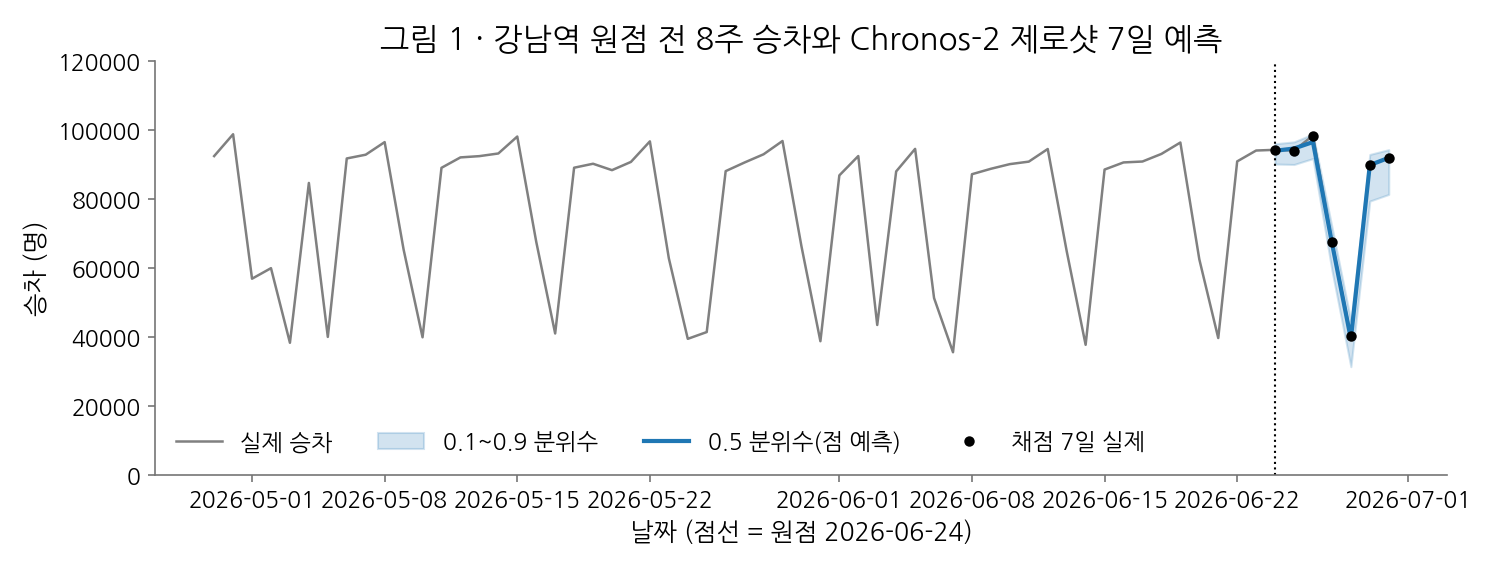

표 3 · 강남역 컨텍스트 512일의 요일별 평균 승차 (명)
컨텍스트 2025-01-28 ~ 2026-06-23 (512일, 마지막 날 = 원점 전날)
            월       화       수       목       금       토       일
평균 승차  84,185  86,126  87,300  88,017  92,868  63,891  37,458

표 4 · 공휴일 있는 세 주의 평일, 100개 역 예측 합 ÷ 실제 합 (배)
평일 공휴일 6일 : 2025-08-15 · 2025-10-03 · 2025-10-06 · 2025-10-07 · 2026-02-16 · 2026-02-17
              평일 공휴일 6일 공휴일 아닌 평일 9일 6일 모두 실제보다 높게 예측한 역
Chronos-2 제로샷    2.139배       1.001배               96개 역
계절 나이브           2.143배       0.998배               95개 역


In [2]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 지하철 100개 역으로 표 1 · 표 2 · 그림 1 · 표 3 · 표 4 를 만듭니다. Chronos-2 는 원점 넷에 한 번씩 부르고 학습은 하지 않습니다
# Chronos-2 를 불러오다 내려받기 오류(Hugging Face)가 나면 맨 위 설치 셀부터 다시 실행합니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import holidays

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 첫날과 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 표 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 표 행의 역 이름

ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                                       # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]                           # 공휴일 있는 세 주
H, CTX = 7, 512                               # 채점 7일 · 컨텍스트 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # Chronos-2 가 내는 분위수 아홉 개 (점 예측은 0.5)
SEED = 0                                      # 시드
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 설치 셀과 같은 규칙, 이 셀만 실행해도 정해집니다
torch.backends.cuda.matmul.allow_tf32 = False            # fp32 로 계산합니다


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지의 100개 역(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden)


# 계절 나이브: 원점 전 7일(1주일 전 같은 요일 값)을 그대로 7일 예측으로 씁니다
SN_MASE = {}                                  # 원점 → 계절 나이브의 100개 역 평균 MASE
for _d in ORIGINS:
    _c = origin_ctx(_d)
    SN_MASE[_d] = float(np.mean(np.abs(_c["test"] - MAT[:, _c["o"] - 7:_c["o"]]) / _c["qden"][:, None]))
SN_PLAIN = float(np.mean([SN_MASE[_d] for _d in PLAIN_ORIGINS]))
SN_HOL = float(np.mean([SN_MASE[_d] for _d in HOL_ORIGINS]))

# Chronos-2 를 DEVICE 에 올리고, 원점마다 100개 역의 원점 전날까지 512일을 롱 포맷 표 하나로 넘겨 7일을 한 번에 받습니다
from chronos import BaseChronosPipeline
_t0 = time.perf_counter()
PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
_load_sec = time.perf_counter() - _t0
_n_st, _g = len(STATIONS), STATIONS.index("2호선 강남")
_point, _t1 = {}, time.perf_counter()        # _point: 원점 → 100개 역 x 7일 점 예측("0.5" 열)
for _d in ["2026-06-24"] + HOL_ORIGINS:
    _o = origin_ctx(_d)["o"]
    _long = pd.DataFrame({"item_id": np.repeat(np.arange(_n_st), CTX),           # 역 · 날짜 · 승차 세 열
                          "timestamp": np.tile(DATES[_o - CTX:_o].values, _n_st),
                          "target": MAT[:, _o - CTX:_o].ravel()})
    torch.manual_seed(SEED)
    _fc = PIPE.predict_df(_long, prediction_length=H, quantile_levels=QS, context_length=CTX, freq="D")
    _fc = _fc.sort_values(["item_id", "timestamp"])
    _point[_d] = _fc["0.5"].to_numpy().reshape(_n_st, H)
    if _d == "2026-06-24":
        _gfc = _fc[_fc["item_id"] == _g]
_pred_sec = time.perf_counter() - _t1

# 표 2 · 표 3 의 값: 강남역 원점 2026-06-24
_o = origin_ctx("2026-06-24")["o"]
GN_FC = pd.DataFrame({"actual": MAT[_g, _o:_o + H], "0.1": _gfc["0.1"].to_numpy(),
                      "0.5": _gfc["0.5"].to_numpy(), "0.9": _gfc["0.9"].to_numpy()}, index=DATES[_o:_o + H])
GN_CTX_LAST = DATES[_o - 1]                   # 컨텍스트 마지막 날 = 원점 전날
_ctx = DATES[_o - CTX:_o]
_DOW = ["월", "화", "수", "목", "금", "토", "일"]
GN_DOW = pd.Series(MAT[_g, _o - CTX:_o], index=_ctx).groupby(_ctx.dayofweek).mean()
GN_DOW.index = _DOW

# 표 4 의 값: 공휴일 있는 세 주의 채점 7일 가운데 평일(월~금)을 공휴일 6일과 공휴일 아닌 날 9일로 나눕니다
_kr = holidays.KR(years=[2025, 2026])
_hol6, _wk9 = [], []                          # (원점, 원점부터 며칠째) 목록
for _d in HOL_ORIGINS:
    for _k in range(H):
        _day = DATES[origin_ctx(_d)["o"] + _k]
        if _day.dayofweek < 5:
            (_hol6 if _day.date() in _kr else _wk9).append((_d, _k))
HOL_DAYS = [str(DATES[origin_ctx(_d)["o"] + _k].date()) for _d, _k in _hol6]
_pred_of = {"Chronos-2 제로샷": lambda d: _point[d],
            "계절 나이브": lambda d: MAT[:, origin_ctx(d)["o"] - 7:origin_ctx(d)["o"]]}


def _sum_ratio(pred, days):
    """고른 날들의 100개 역 예측 합 ÷ 실제 합"""
    return float(sum(pred(_d)[:, _k].sum() for _d, _k in days)
                 / sum(origin_ctx(_d)["test"][:, _k].sum() for _d, _k in days))


HOL_RATIO = pd.DataFrame({"hol6": {m: _sum_ratio(f, _hol6) for m, f in _pred_of.items()},
                          "wk9": {m: _sum_ratio(f, _wk9) for m, f in _pred_of.items()}})
HOL_ALLOVER = {m: int(np.all([f(_d)[:, _k] > origin_ctx(_d)["test"][:, _k] for _d, _k in _hol6], axis=0).sum())
               for m, f in _pred_of.items()}   # 평일 공휴일 6일 모두 실제보다 높게 예측한 역 수

# 자료 확인 (출력 없음) — 계절 나이브 다섯 값, 강남 MASE 분모, 컨텍스트 기간, Chronos-2 가 입력을 16일씩 묶는 패치 크기, 표 4
assert MAT.shape == (100, 4199)
assert [round(SN_MASE[_d], 3) for _d in ORIGINS] == [1.069, 4.388, 0.419, 2.844, 0.471]
assert (round(SN_PLAIN, 3), round(SN_HOL, 3)) == (0.445, 2.767)
assert round(float(origin_ctx("2026-06-24")["qden"][_g]), 1) == 7813.8
assert (str(_ctx[0].date()), str(GN_CTX_LAST.date())) == ("2025-01-28", "2026-06-23")
assert PIPE.model.chronos_config.input_patch_size == 16
assert HOL_DAYS == ["2025-08-15", "2025-10-03", "2025-10-06", "2025-10-07", "2026-02-16", "2026-02-17"]
assert abs(HOL_RATIO.loc["Chronos-2 제로샷", "hol6"] - 2.14) < 0.02 and 94 <= HOL_ALLOVER["Chronos-2 제로샷"] <= 98

print(f"행렬 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print(f"Chronos-2 : amazon/chronos-2 · fp32 · DEVICE {DEVICE} · 불러오기 {_load_sec:.1f}초"
      f" · 원점 넷 예측 {_pred_sec:.1f}초 · 학습 없음")
print()
print("표 1 · 계절 나이브의 예측 원점별 MASE (배)")
_tab1 = pd.DataFrame([SN_MASE], index=["계절 나이브"]).round(3)
_tab1.columns.name = "예측 원점"
print(_tab1.to_string())
print(f"두 묶음 평균 : 공휴일 없는 두 주 {SN_PLAIN:.3f} · 공휴일 있는 세 주 {SN_HOL:.3f}")
print()
print("표 2 · 강남역 원점 2026-06-24 Chronos-2 제로샷 예측과 실제 (명)")
_tab2 = GN_FC.T.round().astype(int).map("{:,}".format)
_tab2.index = ["실제", "0.1 분위수", "0.5 분위수", "0.9 분위수"]
_tab2.columns = [f"{_x:%m-%d}({_DOW[_x.dayofweek]})" for _x in GN_FC.index]
print(_tab2.to_string())

_win = slice(_o - 56, _o + H)                 # 원점 전 8주와 채점 7일
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(DATES[_win], MAT[_g, _win], color="gray", lw=1.2, label="실제 승차")
ax.fill_between(GN_FC.index, GN_FC["0.1"], GN_FC["0.9"], color="tab:blue", alpha=0.2, label="0.1~0.9 분위수")
ax.plot(GN_FC.index, GN_FC["0.5"], color="tab:blue", lw=2, label="0.5 분위수(점 예측)")
ax.plot(GN_FC.index, GN_FC["actual"], "o", color="black", ms=4, label="채점 7일 실제")
ax.axvline(DATES[_o], color="black", ls=":", lw=1)
ax.set_ylim(0, 120000)
ax.set_title("그림 1 · 강남역 원점 전 8주 승차와 Chronos-2 제로샷 7일 예측")
ax.set(xlabel="날짜 (점선 = 원점 2026-06-24)", ylabel="승차 (명)")
ax.legend(loc="lower left", ncol=4, frameon=False)
plt.show()

print("표 3 · 강남역 컨텍스트 512일의 요일별 평균 승차 (명)")
print(f"컨텍스트 {_ctx[0].date()} ~ {GN_CTX_LAST.date()} ({CTX}일, 마지막 날 = 원점 전날)")
print(GN_DOW.round().astype(int).map("{:,}".format).to_frame("평균 승차").T.to_string())
print()
print("표 4 · 공휴일 있는 세 주의 평일, 100개 역 예측 합 ÷ 실제 합 (배)")
print("평일 공휴일 6일 : " + " · ".join(HOL_DAYS))
_tab4 = pd.DataFrame({"평일 공휴일 6일": HOL_RATIO["hol6"].map("{:.3f}배".format),
                    "공휴일 아닌 평일 9일": HOL_RATIO["wk9"].map("{:.3f}배".format),
                    "6일 모두 실제보다 높게 예측한 역": pd.Series(HOL_ALLOVER).map("{}개 역".format)})
print(_tab4.to_string())

In [3]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 첫날과 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 표 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 표 행의 역 이름

ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                                       # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]                           # 공휴일 있는 세 주
H, CTX = 7, 512                               # 채점 7일 · 컨텍스트 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # Chronos-2 가 내는 분위수 아홉 개 (점 예측은 0.5)
SEED = 0                                      # 시드
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 설치 셀과 같은 규칙, 이 셀만 실행해도 정해집니다
torch.backends.cuda.matmul.allow_tf32 = False            # fp32 로 계산합니다


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지의 100개 역(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden)


def score(y, pred, qden):
    """MASE(역마다 분모로 나눈 절대 오차의 평균)와 RMSE(명)를 사전으로 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    q = np.asarray(qden, dtype=float).reshape(-1, 1)
    return dict(mase=float(np.mean(np.abs(y - pred) / q)),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))))


def mase_by_station(y, pred, qden):
    """역마다 MASE(채점 7일 절대 오차 ÷ MASE 분모의 평균)를 구해 100개를 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    return np.mean(np.abs(y - pred) / np.asarray(qden, dtype=float).reshape(-1, 1), axis=1)


SN_ST = {}                                    # 원점 날짜 → 계절 나이브(1주일 전 같은 요일 값)의 역별 MASE 100개
for _d in ORIGINS:
    _c = origin_ctx(_d)
    SN_ST[_d] = mase_by_station(_c["test"], MAT[:, _c["o"] - 7:_c["o"]], _c["qden"])

# Chronos-2 를 DEVICE 에 올립니다. 맨 위 설치 셀이 내려받아 둔 가중치를 읽습니다
from chronos import BaseChronosPipeline
_t0 = time.perf_counter()
PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
_load_sec = time.perf_counter() - _t0

# 자료 확인 (출력 없음) — 계절 나이브의 원점별·두 묶음 평균, Chronos-2 가 입력을 16일씩 묶는 패치 크기
assert [round(float(SN_ST[_d].mean()), 3) for _d in ("2026-06-24", "2025-12-10", "2025-10-01")] == [0.471, 0.419, 4.388]
assert (round(float(np.mean([SN_ST[_d].mean() for _d in PLAIN_ORIGINS])), 3),
        round(float(np.mean([SN_ST[_d].mean() for _d in HOL_ORIGINS])), 3)) == (0.445, 2.767)
assert PIPE.model.chronos_config.input_patch_size == 16

print(f"행렬 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print("원점 5개 :", " · ".join(ORIGINS), f"— 원점마다 원점 전날까지의 {CTX}일을 컨텍스트로 씁니다")
print(f"Chronos-2 : amazon/chronos-2 · fp32 · DEVICE {DEVICE} · 불러오기 {_load_sec:.1f}초 · 학습 없음")
print("쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED"
      " · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · mase_by_station(y, pred, qden) · SN_ST")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

행렬 : 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
원점 5개 : 2025-08-13 · 2025-10-01 · 2025-12-10 · 2026-02-11 · 2026-06-24 — 원점마다 원점 전날까지의 512일을 컨텍스트로 씁니다
Chronos-2 : amazon/chronos-2 · fp32 · DEVICE cuda · 불러오기 1.3초 · 학습 없음
쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · mase_by_station(y, pred, qden) · SN_ST


원점        | 컨텍스트 첫날 ~ 마지막 날   | 계절 나이브 MASE | Chronos-2 MASE | 더 낮은 역 비율
2025-08-13  | 2024-03-19 ~ 2025-08-12 |            1.069 |          1.115 |  34.0%
2025-10-01  | 2024-05-07 ~ 2025-09-30 |            4.388 |          4.238 |  82.0%
2025-12-10  | 2024-07-16 ~ 2025-12-09 |            0.419 |          0.279 |  89.0%
2026-02-11  | 2024-09-17 ~ 2026-02-10 |            2.844 |          2.935 |  12.0%
2026-06-24  | 2025-01-28 ~ 2026-06-23 |            0.471 |          0.263 |  93.0%

공휴일 없는 두 주 제로샷 평균 MASE = 0.271
공휴일 없는 두 주에서 계절 나이브보다 MASE 가 낮은 역 비율 = 91.0%


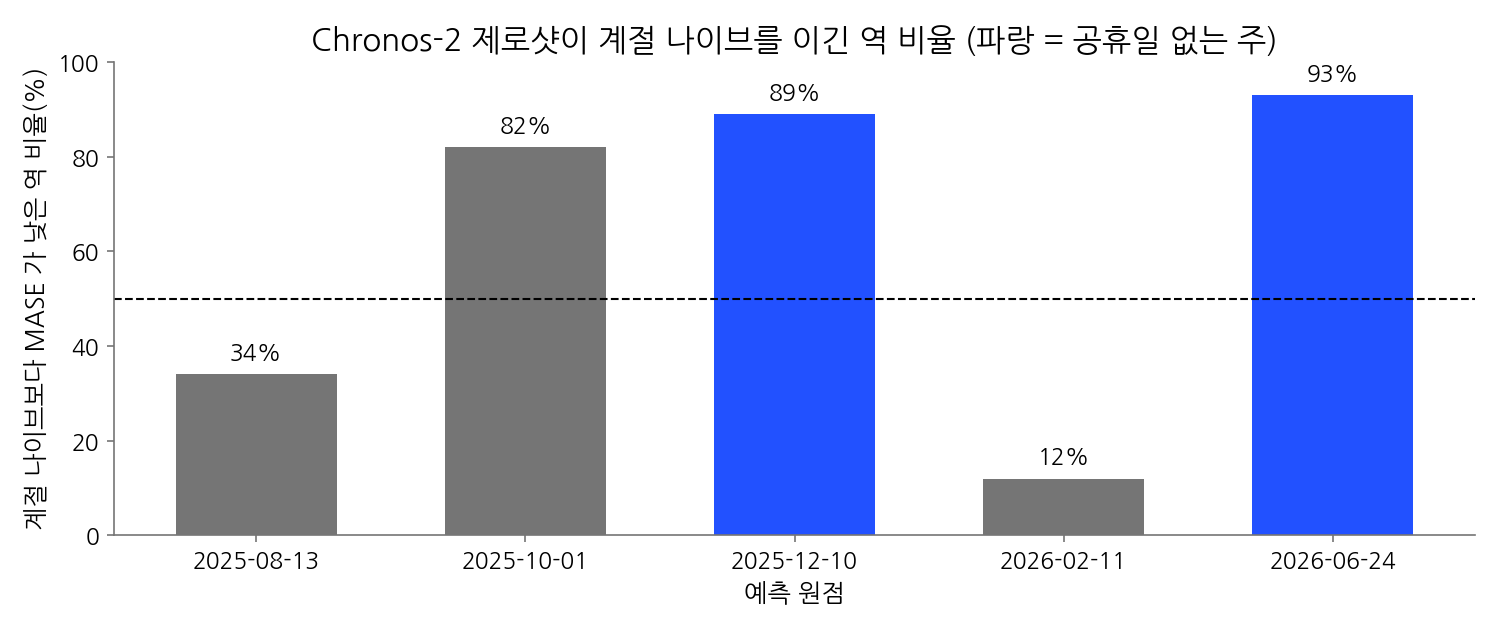

In [4]:
PROMPT = """위 표의 이름과 PIPE 는 다시 만들지 말고 시드 0 으로 예측해 줘. 원점마다 MAT[:, o - CTX:o] 를 item_id · timestamp · target 롱 포맷 표로 만들어(item_id 는 MAT 행 번호 0~99) predict_df 에 prediction_length=H 로 전달하고, 정렬한 "0.5" 열을 100개 역 × 7일로 바꿔 mase_by_station 으로 역별 MASE 를 구한 뒤 SN_ST 와 역끼리 비교해 줘. 원점마다 컨텍스트 첫날·마지막 날, 두 MASE, 비율을 한 행씩 출력하고 "공휴일 없는 두 주 제로샷 평균 MASE = 값" 과 "공휴일 없는 두 주에서 계절 나이브보다 MASE 가 낮은 역 비율 = 값%" 를 한 행씩 출력해 줘. 원점 5개의 비율을 막대로 그리고 50 에 가로 점선, 가로축 「예측 원점」, 세로축 「계절 나이브보다 MASE 가 낮은 역 비율(%)」 이름을 달아 줘."""

# --- 여기부터 AI 코드 ---
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

n_st = len(STATIONS)                 # 100개 역 (item_id = MAT 행 번호 0~99)
CH_ST = {}                           # 원점 → Chronos-2 제로샷 역별 MASE 100개
CH_MASE = {}                         # 원점 → Chronos-2 제로샷 100개 역 평균 MASE
BEAT_PCT = {}                        # 원점 → 계절 나이브보다 MASE 가 낮은 역 비율(%)

print("원점        | 컨텍스트 첫날 ~ 마지막 날   | 계절 나이브 MASE | Chronos-2 MASE | 더 낮은 역 비율")
for d in ORIGINS:
    c = origin_ctx(d)
    o = c["o"]
    # 원점 전날까지의 512일만 롱 포맷으로 (역 순서 = STATIONS 순서)
    long_df = pd.DataFrame({
        "item_id": np.repeat(np.arange(n_st), CTX),
        "timestamp": np.tile(DATES[o - CTX:o].values, n_st),
        "target": MAT[:, o - CTX:o].ravel(),
    })
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    fc = PIPE.predict_df(long_df, prediction_length=H, quantile_levels=QS,
                         context_length=CTX, freq="D")
    fc = fc.sort_values(["item_id", "timestamp"])
    assert len(fc) == n_st * H
    pred = fc["0.5"].to_numpy().reshape(n_st, H)          # 100개 역 × 7일 점 예측

    st = mase_by_station(c["test"], pred, c["qden"])      # 역별 MASE 100개
    CH_ST[d] = st
    CH_MASE[d] = score(c["test"], pred, c["qden"])["mase"]
    BEAT_PCT[d] = float(np.mean(st < SN_ST[d]) * 100)

    print(f"{d}  | {DATES[o - CTX].date()} ~ {DATES[o - 1].date()} | "
          f"{SN_ST[d].mean():16.3f} | {CH_MASE[d]:14.3f} | {BEAT_PCT[d]:5.1f}%")

# 공휴일 없는 두 주: 평균 MASE 와 역별 MASE 200개(100개 역 × 원점 2개) 비교
plain_mase = float(np.mean([CH_MASE[d] for d in PLAIN_ORIGINS]))
ch_200 = np.concatenate([CH_ST[d] for d in PLAIN_ORIGINS])
sn_200 = np.concatenate([SN_ST[d] for d in PLAIN_ORIGINS])
plain_beat = float(np.mean(ch_200 < sn_200) * 100)

print()
print(f"공휴일 없는 두 주 제로샷 평균 MASE = {plain_mase:.3f}")
print(f"공휴일 없는 두 주에서 계절 나이브보다 MASE 가 낮은 역 비율 = {plain_beat:.1f}%")

# 그래프: 원점 5개의 비율 막대 (공휴일 없는 주 = 파랑, 공휴일 있는 주 = 회색)
colors = [COL["파랑"] if d in PLAIN_ORIGINS else COL["회색"] for d in ORIGINS]
fig, ax = plt.subplots(figsize=(FIG_W, 4.2))
bars = ax.bar(ORIGINS, [BEAT_PCT[d] for d in ORIGINS], color=colors, width=0.6)
for b, d in zip(bars, ORIGINS):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 2,
            f"{BEAT_PCT[d]:.0f}%", ha="center", va="bottom", fontsize=11)
ax.axhline(50, color="black", ls="--", lw=1)
ax.set_ylim(0, 100)
ax.set_xlabel("예측 원점")
ax.set_ylabel("계절 나이브보다 MASE 가 낮은 역 비율(%)")
ax.set_title("Chronos-2 제로샷이 계절 나이브를 이긴 역 비율 (파랑 = 공휴일 없는 주)")
plt.show()

In [6]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 첫날과 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 표 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 표 행의 역 이름

ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                                       # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]                           # 공휴일 있는 세 주
H, CTX = 7, 512                               # 채점 7일 · 컨텍스트 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # Chronos-2 가 내는 분위수 아홉 개 (점 예측은 0.5)
SEED = 0                                      # 시드
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 설치 셀과 같은 규칙, 이 셀만 실행해도 정해집니다
torch.backends.cuda.matmul.allow_tf32 = False            # fp32 로 계산합니다


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지의 100개 역(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden)


def score(y, pred, qden):
    """MASE(역마다 분모로 나눈 절대 오차의 평균)와 RMSE(명)를 사전으로 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    q = np.asarray(qden, dtype=float).reshape(-1, 1)
    return dict(mase=float(np.mean(np.abs(y - pred) / q)),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))))


# 전임 담당자가 남긴 보고표. 원점마다 7일을 하루씩 예측하며, 예측할 날의 전날 실측까지
#  입력에 넣어 채점한 제로샷 MASE 입니다. 아래 「PROMPT 셀」의 전임 담당자 코드를 그대로 실행하면
#  이 값이 다시 나옵니다. 고친 코드는 이 값을 쓰고, 하루씩 도는 계산을 다시 실행하지 않습니다.
_g, _o = STATIONS.index("2호선 강남"), int(DATES.get_loc(pd.Timestamp("2026-06-24")))
assert tuple(MAT[_g, _o:_o + 3]) == (94303, 94077, 98456)             # 자료 확인 — 강남 6월 24~26일 실측
REPORTED = {"2025-08-13": 1.078524, "2025-10-01": 3.519137, "2025-12-10": 0.269499,
            "2026-02-11": 2.307275, "2026-06-24": 0.248111}

# Chronos-2 를 DEVICE 에 올립니다. 맨 위 설치 셀이 내려받아 둔 가중치를 읽습니다
from chronos import BaseChronosPipeline
_t0 = time.perf_counter()
PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
_load_sec = time.perf_counter() - _t0

print(f"행렬 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print("원점 5개 :", " · ".join(ORIGINS), f"— 원점마다 원점 전날까지의 {CTX}일을 컨텍스트로 씁니다")
print(f"Chronos-2 : amazon/chronos-2 · fp32 · DEVICE {DEVICE} · 불러오기 {_load_sec:.1f}초 · 학습 없음")
print("전임 담당자의 보고표 (제로샷 MASE, 날마다 다시 예측해 계산) :",
      " · ".join(f"{k} {v:.3f}" for k, v in REPORTED.items()),
      f"(평균 {np.mean(list(REPORTED.values())):.3f})")
print("쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED"
      " · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · REPORTED")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

행렬 : 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
원점 5개 : 2025-08-13 · 2025-10-01 · 2025-12-10 · 2026-02-11 · 2026-06-24 — 원점마다 원점 전날까지의 512일을 컨텍스트로 씁니다
Chronos-2 : amazon/chronos-2 · fp32 · DEVICE cuda · 불러오기 1.3초 · 학습 없음
전임 담당자의 보고표 (제로샷 MASE, 날마다 다시 예측해 계산) : 2025-08-13 1.079 · 2025-10-01 3.519 · 2025-12-10 0.269 · 2026-02-11 2.307 · 2026-06-24 0.248 (평균 1.485)
쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · REPORTED


원점       | 7일 뒤 예측 입력 첫날 ~ 마지막 날 | 원점 뒤 실측 | 보고표 MASE | 한 번에 예측 MASE
2025-08-13 | 2024-03-19 ~ 2025-08-12          |        0일 |       1.079 |            1.115
2025-10-01 | 2024-05-07 ~ 2025-09-30          |        0일 |       3.519 |            4.238
2025-12-10 | 2024-07-16 ~ 2025-12-09          |        0일 |       0.269 |            0.279
2026-02-11 | 2024-09-17 ~ 2026-02-10          |        0일 |       2.307 |            2.935
2026-06-24 | 2025-01-28 ~ 2026-06-23          |        0일 |       0.248 |            0.263

7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수 = 0
7일을 한 번에 예측한 원점 5개 평균 MASE = 1.766
보고표 평균과의 차이 = 0.281


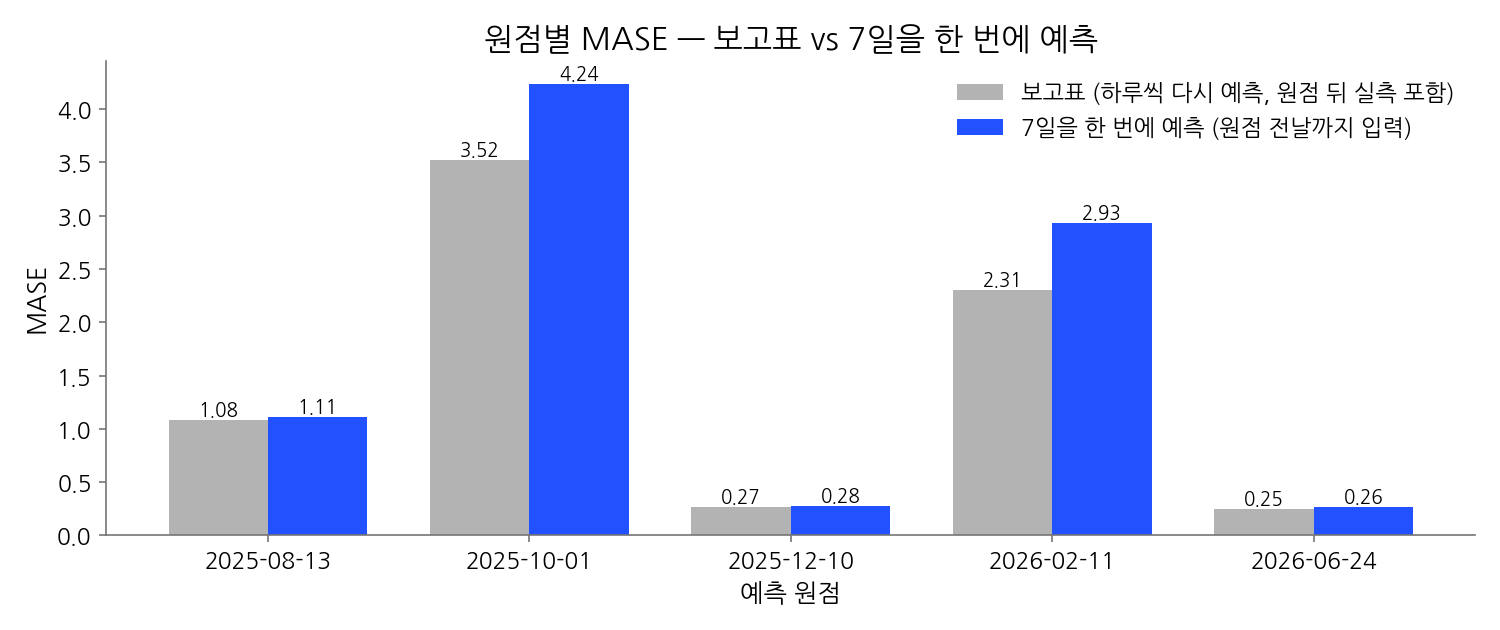

In [7]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
PROMPT = """전임 담당자 코드는 7일을 하루씩 예측하면서 입력 끝을 end = o + h 로 옮겨, h일째 예측의 입력에 원점 뒤 실측이 h일 들어가 있어. 위 이름(MAT · DATES · STATIONS · ORIGINS · H · CTX · QS · SEED · PIPE · origin_ctx · score · REPORTED)과 PIPE 는 다시 만들지 말고, 하루씩 도는 for h 루프를 없애 줘. 원점마다 입력은 원점 전날까지의 512일 MAT[:, o - CTX:o] 로 고정하고(item_id 는 MAT 행 번호 0~99), 시드 0 으로 predict_df 에 prediction_length=H 를 줘서 7일을 한 번에 예측해 줘. item_id · timestamp 로 정렬한 "0.5" 열을 100개 역 × 7일로 바꿔 score 로 원점별 MASE 를 구해 줘.
확인할 값으로 원점마다 7일 뒤 예측(채점 7일째)에 쓴 입력의 첫날·마지막 날과, 그 입력 512일 가운데 날짜가 원점 당일 이후인 날의 개수를 한 행씩 출력하고, 원점별로 REPORTED 값과 고친 MASE 도 함께 출력해 줘.
마지막에 "7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수 = 정수" (원점 5개 가운데 가장 큰 값), "7일을 한 번에 예측한 원점 5개 평균 MASE = 소수 셋째 자리", "보고표 평균과의 차이 = 소수 셋째 자리" (고친 원점 5개 평균 MASE 에서 REPORTED 다섯 값의 평균을 뺀 값)를 한 행씩 출력해 줘. 전임 담당자 출력의 세 문구 「제로샷 평균 MASE」·「판단 :」·「운영 가능」은 어떤 행에도 남기지 마.
그래프는 원점마다 보고표 막대와 한 번에 예측한 막대를 나란히 두고, 가로축 「예측 원점」, 세로축 「MASE」 이름과 범례를 달아 줘."""
# --- 여기부터 AI 코드 ---
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

n_st = len(STATIONS)
mase_fixed = {}                      # 원점 → 7일을 한 번에 예측한 MASE
leak_days = {}                       # 원점 → 7일 뒤 예측 입력 중 원점 당일 이후 날짜 수

print("원점       | 7일 뒤 예측 입력 첫날 ~ 마지막 날 | 원점 뒤 실측 | 보고표 MASE | 한 번에 예측 MASE")
for origin in ORIGINS:
    c = origin_ctx(origin)
    o = c["o"]
    ctx_dates = DATES[o - CTX:o]                                  # 입력 끝 = 원점 전날로 고정
    long_df = pd.DataFrame({"item_id": np.repeat(np.arange(n_st), CTX),
                            "timestamp": np.tile(ctx_dates.values, n_st),
                            "target": MAT[:, o - CTX:o].ravel()})
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    fc = PIPE.predict_df(long_df, prediction_length=H, quantile_levels=QS,
                         context_length=CTX, freq="D")            # 7일을 한 번에
    fc = fc.sort_values(["item_id", "timestamp"])
    assert len(fc) == n_st * H
    pred = fc["0.5"].to_numpy().reshape(n_st, H)

    mase_fixed[origin] = score(c["test"], pred, c["qden"])["mase"]
    # 7일 뒤 예측도 같은 입력(ctx_dates)을 씁니다 — 원점 당일 이후 날짜를 셉니다
    leak_days[origin] = int((ctx_dates >= pd.Timestamp(origin)).sum())

    print(f"{origin} | {ctx_dates[0].date()} ~ {ctx_dates[-1].date()}          | "
          f"{leak_days[origin]:>8d}일 | {REPORTED[origin]:11.3f} | {mase_fixed[origin]:16.3f}")

fixed_mean = float(np.mean([mase_fixed[o] for o in ORIGINS]))
reported_mean = float(np.mean([REPORTED[o] for o in ORIGINS]))
max_leak = max(leak_days.values())

print()
print(f"7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수 = {max_leak}")
print(f"7일을 한 번에 예측한 원점 5개 평균 MASE = {fixed_mean:.3f}")
print(f"보고표 평균과의 차이 = {fixed_mean - reported_mean:.3f}")

# 그래프: 원점마다 보고표(하루씩, 누수) 막대와 한 번에 예측한 막대
x = np.arange(len(ORIGINS))
w = 0.38
fig, ax = plt.subplots(figsize=(FIG_W, 4.2))
ax.bar(x - w / 2, [REPORTED[o] for o in ORIGINS], width=w, color=COL["연회색"],
       label="보고표 (하루씩 다시 예측, 원점 뒤 실측 포함)")
ax.bar(x + w / 2, [mase_fixed[o] for o in ORIGINS], width=w, color=COL["파랑"],
       label="7일을 한 번에 예측 (원점 전날까지 입력)")
for i, o in enumerate(ORIGINS):
    ax.text(x[i] - w / 2, REPORTED[o], f"{REPORTED[o]:.2f}", ha="center", va="bottom", fontsize=9)
    ax.text(x[i] + w / 2, mase_fixed[o], f"{mase_fixed[o]:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(ORIGINS)
ax.set_xlabel("예측 원점")
ax.set_ylabel("MASE")
ax.set_title("원점별 MASE — 보고표 vs 7일을 한 번에 예측")
ax.legend(frameon=False, loc="upper right")
plt.show()